In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

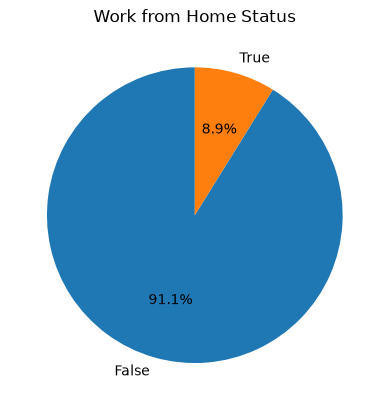

In [9]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.title('Work from Home Status')
plt.show()


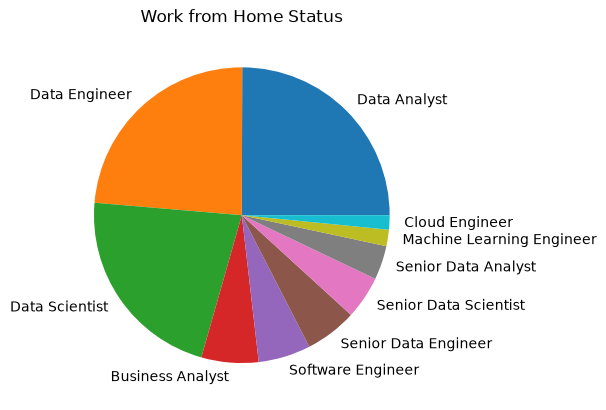

In [6]:
df['job_title_short'].value_counts().plot(kind='pie')
plt.title('Work from Home Status')
plt.show()

In [12]:
df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


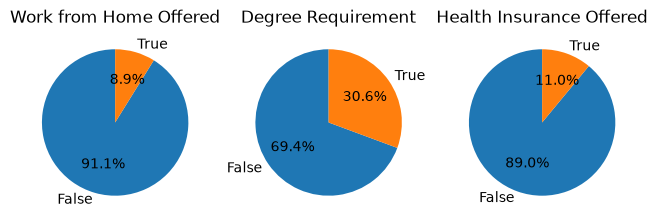

In [26]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax=plt.subplots(1,3)

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

# Problems

Text(0.5, 1.0, 'Proportion of Data Analyst Jobs Mentioning Health Insurance')

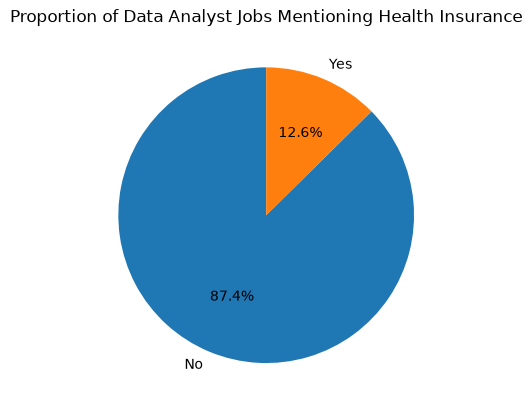

In [ ]:
df_DA = df[df['job_title_short'] == 'Data Analyst']

df_DA['job_health_insurance'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', labels= ['No', 'Yes'])
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')

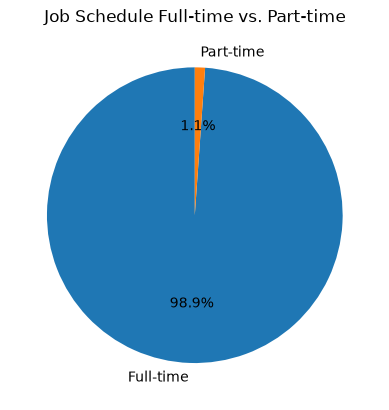

In [ ]:
schedule = ['Full-time', 'Part-time']
df_ft_pt = df[df['job_schedule_type'].isin(schedule)]

df_ft_pt['job_schedule_type'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', labels=df_ft_pt['job_schedule_type'].value_counts().index)
plt.title('Job Schedule Full-time vs. Part-time')
plt.show()

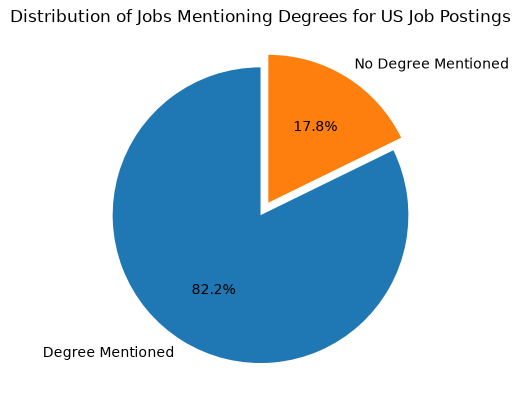

In [ ]:
df_US = df[df['job_country'] == 'United States'].copy()
degree_counts = df_US['job_no_degree_mention'].value_counts()
plt.pie(degree_counts, labels=['Degree Mentioned', 'No Degree Mentioned'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()